# Final-QC retention by recycle across all protocols

This notebook asks a focused QC question: **how many nominal seed/model trajectories are represented in the final-QC ensemble at each AlphaFold recycle?**

The primary figure uses the complete nominal cohort of 100 seeds × five model trajectories = 500 trajectories per protocol. A secondary sensitivity figure shows the first 20 seeds (100 nominal trajectories) beside the complete cohort. Missing trajectories are never replaced.

Cell labels are retained counts. CaV1.2, Kv2.1, and NaV1.5 use their project-specific blue, green, and purple gradients. Kv2.1 uses its stricter structural-interface/alignment-QC tables, so absolute retention should be compared primarily between vanilla and masked within a Kv2.1 condition rather than directly against the other channel families.

In [7]:
from pathlib import Path
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

repo_root = Path.cwd() if (Path.cwd()/'shared').is_dir() else Path.cwd().parent
from shared.plotting import CAV12_PALETTE, KV21_PALETTE, NAV15_PALETTE

sns.set_theme(style='white', context='notebook')
FIG = repo_root/'docs'/'figures'/'recycle_retention'
TAB = repo_root/'docs'/'tables'/'recycle_retention'
FIG.mkdir(parents=True, exist_ok=True)
TAB.mkdir(parents=True, exist_ok=True)

## Final-QC datasets

In [8]:
DATASETS = {
    'CaV1.2 WT': {'channel':'CaV1.2','condition':'WT','vanilla':repo_root/'cav12/dataDistances/26-02-10_Cav12_wt_vanillaAF2_distances_all_ok_rmsd_3A.csv','masked':repo_root/'cav12/dataDistances/26-02-10_Cav12_wt_maskedAF2_distances_all_ok_rmsd_3A.csv'},
    'CaV1.2 G402S': {'channel':'CaV1.2','condition':'G402S','vanilla':repo_root/'cav12/dataDistances/26-02-10_Cav12_g402s_vanillaAF2_distances_all_ok_rmsd_3A.csv','masked':repo_root/'cav12/dataDistances/26-02-10_Cav12_g402s_maskedAF2_distances_all_ok_rmsd_3A.csv'},
    'CaV1.2 G406R': {'channel':'CaV1.2','condition':'G406R','vanilla':repo_root/'cav12/dataDistances/26-02-10_Cav12_g406r_vanillaAF2_distances_all_ok_rmsd_3A.csv','masked':repo_root/'cav12/dataDistances/26-02-10_Cav12_g406r_maskedAF2_distances_all_ok_rmsd_3A.csv'},
    'Kv2.1 WT': {'channel':'Kv2.1','condition':'WT','vanilla':repo_root/'kv21/dataDistances/26-02-11_Kv2.1_wt_vanillaAF2_distances_all_ok_rmsd_3A_structural_interface_alignment_qc.csv','masked':repo_root/'kv21/dataDistances/26-02-11_Kv2.1_wt_maskedAF2_distances_all_ok_rmsd_3A_structural_interface_alignment_qc.csv'},
    'Kv2.1 L403A': {'channel':'Kv2.1','condition':'L403A','vanilla':repo_root/'kv21/dataDistances/26-02-11_Kv2.1_l403a_vanillaAF2_distances_all_ok_rmsd_3A_structural_interface_alignment_qc.csv','masked':repo_root/'kv21/dataDistances/26-02-11_Kv2.1_l403a_maskedAF2_distances_all_ok_rmsd_3A_structural_interface_alignment_qc.csv'},
    'Kv2.1 F412L': {'channel':'Kv2.1','condition':'F412L','vanilla':repo_root/'kv21/dataDistances/26-02-11_Kv2.1_f412l_vanillaAF2_distances_all_ok_rmsd_3A_structural_interface_alignment_qc.csv','masked':repo_root/'kv21/dataDistances/26-02-11_Kv2.1_f412l_maskedAF2_distances_all_ok_rmsd_3A_structural_interface_alignment_qc.csv'},
    'NaV1.5 QQQ': {'channel':'NaV1.5','condition':'QQQ','vanilla':repo_root/'nav15/dataDistances/26-07-27_Nav15_qqq_vanilla_AF2_distances_all_ok_rmsd_3A.csv','masked':repo_root/'nav15/dataDistances/26-07-27_Nav15_qqq_masked_AF2_distances_all_ok_rmsd_3A.csv'},
}
path_audit=pd.DataFrame([{'dataset':name,'protocol':protocol,'path':str(cfg[protocol]),'exists':cfg[protocol].is_file()} for name,cfg in DATASETS.items() for protocol in ('vanilla','masked')])
display(path_audit)
assert path_audit.exists.all()

,dataset,protocol,path,exists
0,CaV1.2 WT,vanilla,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True
1,CaV1.2 WT,masked,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True
2,CaV1.2 G402S,vanilla,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True
3,CaV1.2 G402S,masked,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True
4,CaV1.2 G406R,vanilla,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True
5,CaV1.2 G406R,masked,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True
6,Kv2.1 WT,vanilla,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True
7,Kv2.1 WT,masked,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True
8,Kv2.1 L403A,vanilla,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True
9,Kv2.1 L403A,masked,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True


## Calculate retained trajectories per recycle

Each retained CSV row is a single recycle snapshot. Seed and recycle identifiers are parsed from `pdb_file`. Counts are computed separately for the complete 500-trajectory cohort and the fixed first-100 cohort. Because the allOK3 procedure retains the converged suffix of a trajectory, increasing counts across recycles show when trajectories enter the retained ensemble.

In [9]:
seed_re=re.compile(r'_seed_(\d+)',re.I)
recycle_re=re.compile(r'\.r(\d+)\.pdb$',re.I)
rows=[]
for dataset,cfg in DATASETS.items():
    for protocol in ('vanilla','masked'):
        frame=pd.read_csv(cfg[protocol],usecols=['pdb_file'])
        names=frame.pdb_file.astype(str)
        parsed=pd.DataFrame({'seed':pd.to_numeric(names.str.extract(seed_re,expand=False),errors='coerce'),'recycle':pd.to_numeric(names.str.extract(recycle_re,expand=False),errors='coerce'),'pdb_file':names}).dropna()
        parsed[['seed','recycle']]=parsed[['seed','recycle']].astype(int)
        first_seeds=sorted(parsed.seed.unique())[:20]
        for cohort,part,denominator in [('Nominal first 100',parsed[parsed.seed.isin(first_seeds)],100),('Full 500',parsed,500)]:
            counts=part.groupby('recycle').pdb_file.nunique()
            for recycle in range(1,11):
                retained=int(counts.get(recycle,0))
                rows.append({'channel':cfg['channel'],'dataset':dataset,'condition':cfg['condition'],'protocol':protocol,'cohort':cohort,'recycle':recycle,'nominal':denominator,'retained':retained,'excluded':denominator-retained,'retained_fraction':retained/denominator})
retention=pd.DataFrame(rows)
retention.to_csv(TAB/'cross_project_recycle_retention.csv',index=False)
display(retention)

,channel,dataset,condition,protocol,cohort,recycle,nominal,retained,excluded,retained_fraction
0,CaV1.2,CaV1.2 WT,WT,vanilla,Nominal first 100,1,100,100,0,1.0
1,CaV1.2,CaV1.2 WT,WT,vanilla,Nominal first 100,2,100,100,0,1.0
2,CaV1.2,CaV1.2 WT,WT,vanilla,Nominal first 100,3,100,100,0,1.0
3,CaV1.2,CaV1.2 WT,WT,vanilla,Nominal first 100,4,100,100,0,1.0
4,CaV1.2,CaV1.2 WT,WT,vanilla,Nominal first 100,5,100,100,0,1.0
...,...,...,...,...,...,...,...,...,...,...
275,NaV1.5,NaV1.5 QQQ,QQQ,masked,Full 500,6,500,500,0,1.0
276,NaV1.5,NaV1.5 QQQ,QQQ,masked,Full 500,7,500,500,0,1.0
277,NaV1.5,NaV1.5 QQQ,QQQ,masked,Full 500,8,500,500,0,1.0
278,NaV1.5,NaV1.5 QQQ,QQQ,masked,Full 500,9,500,500,0,1.0


## Primary figure: all 500 nominal trajectories

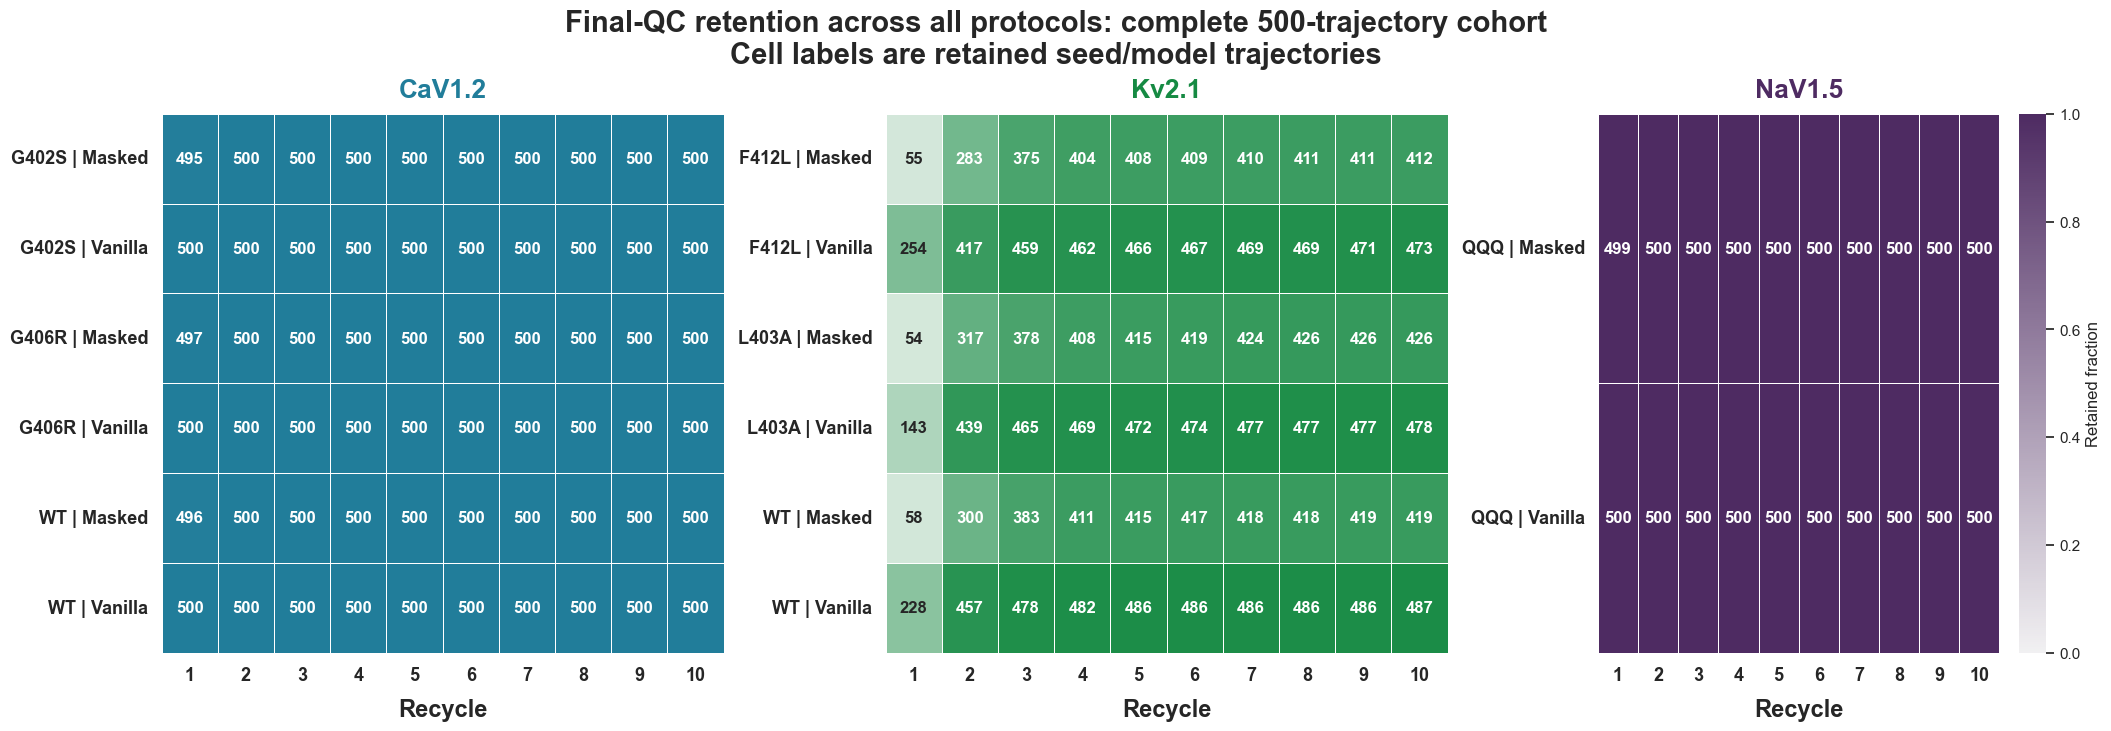

In [10]:
channel_order=['CaV1.2','Kv2.1','NaV1.5']
channel_colors={'CaV1.2':CAV12_PALETTE['G406R_HM'],'Kv2.1':KV21_PALETTE['L403A_HM'],'NaV1.5':NAV15_PALETTE['QQQ_HM']}

def matrix(channel,cohort,value):
    part=retention[(retention.channel==channel)&(retention.cohort==cohort)].copy()
    part['row']=part.dataset.str.replace(r'^(CaV1\.2|Kv2\.1|NaV1\.5)\s+','',regex=True)+' | '+part.protocol.str.capitalize()
    return part.pivot(index='row',columns='recycle',values=value)

fig,axes=plt.subplots(1,3,figsize=(21,7.2),gridspec_kw={'width_ratios':[1.05,1.05,.75]},constrained_layout=True)
for ax,channel in zip(axes,channel_order):
    values=matrix(channel,'Full 500','retained_fraction')
    labels=matrix(channel,'Full 500','retained').map(lambda x:f'{int(x)}')
    sns.heatmap(values,cmap=sns.light_palette(channel_colors[channel],as_cmap=True),vmin=0,vmax=1,annot=labels,fmt='',linewidths=.7,linecolor='white',cbar=channel=='NaV1.5',cbar_kws={'label':'Retained fraction'},annot_kws={'fontsize':12,'fontweight':'bold'},ax=ax)
    ax.set_title(channel,color=channel_colors[channel],fontweight='bold',fontsize=19,pad=12)
    ax.set_xlabel('Recycle',fontsize=17,fontweight='bold',labelpad=10); ax.set_ylabel('')
    ax.tick_params(axis='x',rotation=0,labelsize=13); ax.tick_params(axis='y',rotation=0,labelsize=13)
    for label in ax.get_yticklabels(): label.set_fontweight('bold')
    for label in ax.get_xticklabels(): label.set_fontweight('bold')
fig.suptitle('Final-QC retention across all protocols: complete 500-trajectory cohort\nCell labels are retained seed/model trajectories',fontsize=21,fontweight='bold')
fig.savefig(FIG/'all_protocols_full500_retained_by_recycle.png',dpi=400,bbox_inches='tight',facecolor='white')
fig.savefig(FIG/'all_protocols_full500_retained_by_recycle.pdf',bbox_inches='tight',facecolor='white')
display(fig); plt.close(fig)

## Secondary figure: first 100 versus all 500

This sensitivity view checks whether the recycle-retention pattern in the first 20 seeds resembles the full cohort. The color scale is a fraction, so the two nominal cohort sizes remain comparable; annotations remain raw retained counts.

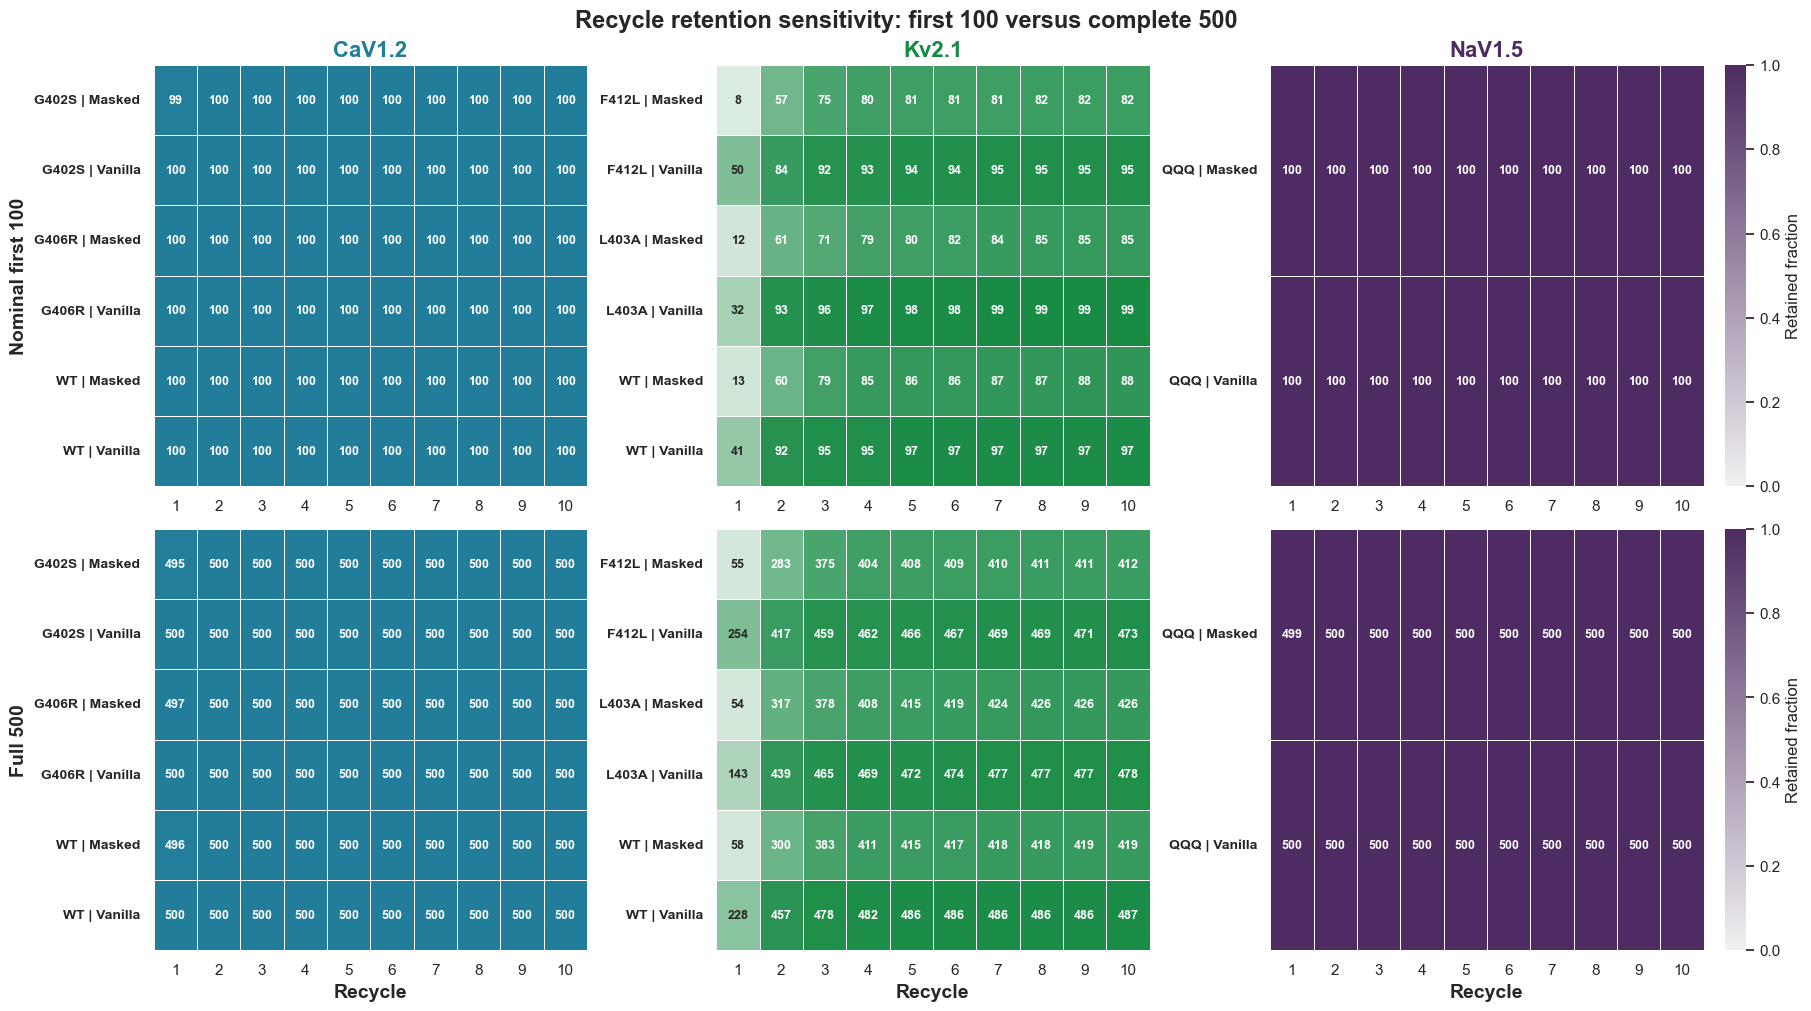

In [11]:
fig,axes=plt.subplots(2,3,figsize=(18,10),constrained_layout=True)
for row,cohort in enumerate(['Nominal first 100','Full 500']):
    for col,channel in enumerate(channel_order):
        ax=axes[row,col]; values=matrix(channel,cohort,'retained_fraction'); labels=matrix(channel,cohort,'retained').map(lambda x:f'{int(x)}')
        sns.heatmap(values,cmap=sns.light_palette(channel_colors[channel],as_cmap=True),vmin=0,vmax=1,annot=labels,fmt='',linewidths=.45,linecolor='white',cbar=col==2,cbar_kws={'label':'Retained fraction'},annot_kws={'fontsize':9,'fontweight':'bold'},ax=ax)
        ax.set_title(channel if row==0 else '',color=channel_colors[channel],fontweight='bold',fontsize=16)
        ax.set_xlabel('Recycle' if row==1 else '',fontsize=14,fontweight='bold'); ax.set_ylabel(cohort if col==0 else '',fontsize=14,fontweight='bold')
        ax.tick_params(axis='x',rotation=0,labelsize=11); ax.tick_params(axis='y',rotation=0,labelsize=10)
        for label in ax.get_yticklabels(): label.set_fontweight('bold')
fig.suptitle('Recycle retention sensitivity: first 100 versus complete 500',fontsize=17,fontweight='semibold')
fig.savefig(FIG/'all_protocols_first100_vs_full500_retained_by_recycle.png',dpi=400,bbox_inches='tight',facecolor='white')
display(fig); plt.close(fig)

## Final-recycle retention summary

In [12]:
final=retention[retention.recycle==10].copy()
summary=final.pivot_table(index=['channel','dataset','protocol'],columns='cohort',values=['retained','retained_fraction']).reset_index()
summary.to_csv(TAB/'final_recycle_retention_summary.csv',index=False)
display(summary)

channel       dataset protocol retained                    \
cohort                                Full 500 Nominal first 100   
0       CaV1.2  CaV1.2 G402S   masked    500.0             100.0   
1       CaV1.2  CaV1.2 G402S  vanilla    500.0             100.0   
2       CaV1.2  CaV1.2 G406R   masked    500.0             100.0   
3       CaV1.2  CaV1.2 G406R  vanilla    500.0             100.0   
4       CaV1.2     CaV1.2 WT   masked    500.0             100.0   
5       CaV1.2     CaV1.2 WT  vanilla    500.0             100.0   
6        Kv2.1   Kv2.1 F412L   masked    412.0              82.0   
7        Kv2.1   Kv2.1 F412L  vanilla    473.0              95.0   
8        Kv2.1   Kv2.1 L403A   masked    426.0              85.0   
9        Kv2.1   Kv2.1 L403A  vanilla    478.0              99.0   
10       Kv2.1      Kv2.1 WT   masked    419.0              88.0   
11       Kv2.1      Kv2.1 WT  vanilla    487.0              97.0   
12      NaV1.5    NaV1.5 QQQ   masked    500.0             100.0   
13      NaV1.5    NaV1.5 QQQ  vanilla    500.0             100.0   

       retained_fraction                    
cohort          Full 500 Nominal first 100  
0                  1.000              1.00  
1                  1.000              1.00  
2                  1.000              1.00  
3                  1.000              1.00  
4                  1.000              1.00  
5                  1.000              1.00  
6                  0.824              0.82  
7                  0.946              0.95  
8                  0.852              0.85  
9                  0.956              0.99  
10                 0.838              0.88  
11                 0.974              0.97  
12                 1.000              1.00  
13                 1.000              1.00